# House Price Prediction Using Linear Regression

## Objective
The objective of this project is to build a predictive model using linear regression to estimate house prices based on relevant numerical features. This project demonstrates the complete machine learning workflow, including data exploration, preprocessing, model training, evaluation, and visualization of results.

## Dataset Description
The dataset contains information about houses such as area, number of bedrooms, bathrooms, parking availability, and other features that influence house prices. The target variable is the house price, which is predicted using linear regression.

## Learning Outcomes
- Understanding the fundamentals of linear regression  
- Gaining hands-on experience in building a predictive model  
- Evaluating model performance using appropriate metrics  
- Interpreting results using visualizations

## Data Loading and Initial Exploration

The housing dataset is loaded into the notebook to understand its structure and contents. Initial exploration is performed to examine the number of records, feature names, data types, and a preview of the data. This helps in identifying the target variable and understanding the overall dataset before preprocessing.

In [1]:
import pandas as pd

df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
df.shape

(545, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Data Cleaning

This section focuses on improving data quality by handling missing values, checking data types, and ensuring the dataset is suitable for building a linear regression model.

In [5]:
# Check for missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
# Fill missing numerical values with median
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

## Encoding Categorical Variables

Since linear regression requires numerical inputs, categorical features are converted into numerical form using one-hot encoding.

In [9]:
# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, drop_first=True)

In [10]:
df.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

## Feature Selection

In this step, the target variable (house price) is separated from the input features.
This allows the linear regression model to learn the relationship between house attributes and the price.

In [11]:
# Separate features and target variable
X = df.drop('price', axis=1)
y = df['price']

# Verify shapes
X.shape, y.shape

((545, 13), (545,))

## Train–Test Split

To evaluate the performance of the linear regression model, the dataset is divided into training and testing sets.
The training set is used to train the model, while the testing set is used to assess its performance on unseen data.

In [12]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify split sizes
X_train.shape, X_test.shape

((436, 13), (109, 13))

## Model Training using Linear Regression

In this step, a Linear Regression model is trained using the training dataset.
The model learns the relationship between the selected features and the target variable (house price) to make future predictions.

In [13]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Display trained model
lr_model

LinearRegression()

## Model Evaluation

In this step, the performance of the Linear Regression model is evaluated using standard regression metrics.
These metrics help determine how accurately the model predicts house prices on unseen test data.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = lr_model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mse, rmse, r2

(1754318687330.6643, np.float64(1324506.9600914388), 0.6529242642153184)

## Visualization: Actual vs Predicted House Prices

This visualization compares the actual house prices with the prices predicted by the Linear Regression model. 
If the model performs well, the points will lie close to the diagonal reference line, indicating accurate predictions.

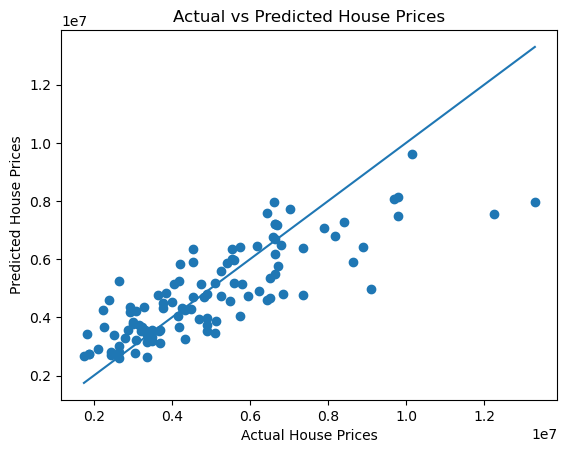

In [15]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)

# Reference line for perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

# Labels and title
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Conclusion

In this project, a Linear Regression model was successfully developed to predict house prices using relevant numerical and categorical features. The dataset was carefully explored and cleaned, and categorical variables were converted into numerical form using one-hot encoding to make them suitable for model training.

The model was trained on a separate training set and evaluated on unseen test data using standard regression metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²). The obtained R² value indicates that the model explains a significant portion of the variance in house prices, demonstrating reasonable predictive performance.

The visualization comparing actual and predicted house prices further supports the evaluation results, showing that many predictions lie close to the ideal reference line. Overall, this project provides practical experience in implementing linear regression, performing data preprocessing, evaluating model performance, and interpreting results in a real-world regression problem.